In [4]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neural_net import NeuralNet
import mushrooms as shroom
import graphics
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
X = np.array(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)

In [7]:
y = np.astype(y, int)
y_processed = np.zeros((len(y), 10))
for i, y_p in enumerate(y_processed):
    y_p[y[i]] =1

y = y_processed 
X = X/255
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [10]:
neural_net = NeuralNet((28**2, 512, 10), learning_rate=0.01, random_state=42)
neural_net.layers[0].activation_method="ReLu"
neural_net.layers[0].initialize("He")
neural_net.layers[-1].activation_method="softmax"
epochs = 10
losses, y_pred = neural_net.train(X_train, y_train, epochs, 128, validate=(X_test, y_test), binary=True)

EPOCH: 1    LOSS: 0.0568181    LOSS CHANGE: 0    TEST ACCURACY: 0.904    TEST ACCURACY CHANGE: 0.904
EPOCH: 2    LOSS: 0.0394599    LOSS CHANGE: -0.01736    TEST ACCURACY: 0.915    TEST ACCURACY CHANGE: 0.0107
EPOCH: 3    LOSS: 0.0362944    LOSS CHANGE: -0.003166    TEST ACCURACY: 0.92    TEST ACCURACY CHANGE: 0.00521
EPOCH: 4    LOSS: 0.0345069    LOSS CHANGE: -0.001788    TEST ACCURACY: 0.922    TEST ACCURACY CHANGE: 0.00171
EPOCH: 5    LOSS: 0.0332717    LOSS CHANGE: -0.001235    TEST ACCURACY: 0.925    TEST ACCURACY CHANGE: 0.00307
EPOCH: 6    LOSS: 0.0322039    LOSS CHANGE: -0.001068    TEST ACCURACY: 0.926    TEST ACCURACY CHANGE: 0.000857
EPOCH: 7    LOSS: 0.0314436    LOSS CHANGE: -0.0007604    TEST ACCURACY: 0.926    TEST ACCURACY CHANGE: 0.000143
EPOCH: 8    LOSS: 0.030679    LOSS CHANGE: -0.0007646    TEST ACCURACY: 0.927    TEST ACCURACY CHANGE: 0.00121
EPOCH: 9    LOSS: 0.0301622    LOSS CHANGE: -0.0005168    TEST ACCURACY: 0.929    TEST ACCURACY CHANGE: 0.00193
EPOCH: 10 

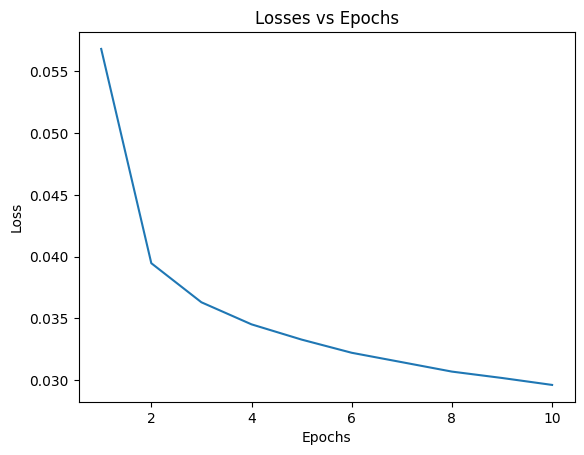

In [11]:
graphics.plot_losses(epochs, losses)

Accuracy: 0.9287142857142857


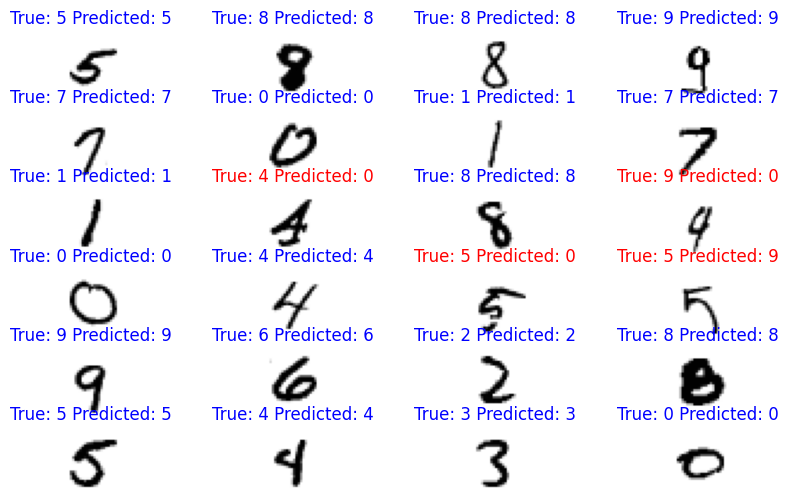

In [13]:
from sklearn.metrics import accuracy_score

y_pred = neural_net.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(f"Accuracy: {accuracy_score(y_pred, y_test)}")

def display_num(ax, X, i, true, pred):
    X_image = np.swapaxes(np.array(np.split(X, 28, axis=1)), 1, 0)
    ax.imshow(X_image[i], cmap="gray_r")
    ax.set_title(f'True: {true} Predicted: {pred}', c="blue" if true == pred else "red")
    ax.axis('off') # Hide axis ticks

rows = 6
cols = 4

fig, axs = plt.subplots(rows, cols, figsize=(10, 6))


for i in range(24):
    current_row = i // cols
    current_col = i % cols
    
    # Select the correct subplot axis
    ax = axs[current_row, current_col]
    display_num(ax, X_test, i+100, y_test.argmax(axis=1)[i+100], y_pred.argmax(axis=1)[i+100])
    #print(f"Prediction: {y_pred.argmax(axis=1)[i]}")